In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import StratifiedTable

In [149]:
# Load the files
metadata = pd.read_csv('../../old/Final_65.csv')
mob_results = pd.read_csv('master_mobtyper_results.csv')

In [249]:
mob_results

,Sample,sample_id,num_contigs,size,gc,md5,rep_type(s),rep_type_accession(s),relaxase_type(s),relaxase_type_accession(s),...,mash_neighbor_identification,primary_cluster_id,secondary_cluster_id,predicted_host_range_overall_rank,predicted_host_range_overall_name,observed_host_range_ncbi_rank,observed_host_range_ncbi_name,reported_host_range_lit_rank,reported_host_range_lit_name,associated_pmid(s)
0,GCA_002038285.1,GCA_002038285.1_ASM203828v1_genomic.fna:AB461,2,58406,0.518200,de8aa6486c96dc9b38c4e31eaebd3507,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,order,Enterobacterales,order,Enterobacterales,order,Enterobacterales,11254626; 19482926; 15781495; 20851899; 16257053
1,GCA_002038445.1,GCA_002038445.1_ASM203844v1_genomic.fna:AB461,12,51056,0.509879,59cdba04bb2dc7fd54c2b9387f6fa754,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,order,Enterobacterales,order,Enterobacterales,order,Enterobacterales,11254626; 19482926; 15781495; 20851899; 16257053
2,GCA_002038485.1,GCA_002038485.1_ASM203848v1_genomic.fna:AB461,3,59545,0.519674,497670db5760d6b481df9f35a7d84104,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,order,Enterobacterales,order,Enterobacterales,order,Enterobacterales,11254626; 19482926; 15781495; 20851899; 16257053
3,GCA_002038585.1,GCA_002038585.1_ASM203858v1_genomic.fna:AB461,2,59408,0.519509,b5f1c830251d99807a8a1068f0153aca,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,order,Enterobacterales,order,Enterobacterales,order,Enterobacterales,11254626; 19482926; 15781495; 20851899; 16257053
4,GCA_002038665.1,GCA_002038665.1_ASM203866v1_genomic.fna:AB461,2,59490,0.519517,833d6f0af0a232a2a3772c9b1d55ab25,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,genus,Salmonella,genus,Salmonella,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,GCA_037003885.1,GCA_037003885.1_ASM3700388v1_genomic.fna:AB712,1,24611,0.446386,7ed6b9c1cd39a1e6ae2975b783e27e89,IncX1,000216__CP009767_00121,MOBP,NC_019096_00001,...,Salmonella enterica subsp. enterica serovar En...,AB712,AK597,order,Enterobacterales,order,Enterobacterales,family,Enterobacteriaceae,21625636; 22470007
84,GCA_041411215.1,GCA_041411215.1_ASM4141121v1_genomic.fna:AB461,1,59370,0.519437,ba4ce9feaa782bd8252a4e267b03a939,"IncFIB,IncFII","000101__NZ_CP012345_00042,000114__CP015527",-,-,...,Salmonella enterica subsp. enterica serovar En...,AB461,AK250,genus,Salmonella,genus,Salmonella,-,-,-
85,GCA_041411215.1,GCA_041411215.1_ASM4141121v1_genomic.fna:AB233,1,61547,0.486263,7cdf2da921eba7bfa925dc52ff3e0190,"IncX1,IncX3","000215__KC853434_00019,JN247852",MOBP,NC_019096_00001,...,Escherichia coli,AB233,AJ920,order,Enterobacterales,order,Enterobacterales,-,-,-
86,GCA_045376435.1,GCA_045376435.1_ASM4537643v1_genomic.fna:AB461,2,84119,0.498227,d9cb2b27a85851a953b9478bd3cc870a,"IncFIB,IncFII,IncX1","000101__NZ_CP012345_00042,000114__CP015527,000...",MOBP,NC_019096_00001,...,Salmonella enterica,AB461,AK249,order,Enterobacterales,order,Enterobacterales,-,-,-


In [193]:
try:
    pf_wide = pd.read_csv('../data/plasmidfinder_replicons_wide.tsv', sep='\t')
except FileNotFoundError:
    # If not found, I'll simulate it with the core columns if I can't find the source.
    # But usually, it should be in the directory.
    pass

In [195]:
# Preprocessing
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})

In [197]:
# Aggregating MOB-suite data
plasmid_counts = mob_results.groupby('Sample').size().reset_index(name='plasmid_count')
mobility_summary = mob_results.groupby('Sample')['predicted_mobility'].unique().reset_index()
mobility_summary['has_conjugative'] = mobility_summary['predicted_mobility'].apply(lambda x: 1 if 'conjugative' in x else 0)
mobility_summary['has_mobilizable'] = mobility_summary['predicted_mobility'].apply(lambda x: 1 if 'mobilizable' in x else 0)

In [199]:
# Merging
merged_df = pd.merge(metadata, plasmid_counts, left_on='Assembly', right_on='Sample', how='left').fillna({'plasmid_count': 0})
merged_df = pd.merge(merged_df, mobility_summary[['Sample', 'has_conjugative', 'has_mobilizable']], left_on='Assembly', right_on='Sample', how='left').fillna(0)

In [201]:
# Try to get replicon data
try:
    pf_wide = pd.read_csv('plasmidfinder_replicons_wide.tsv', sep='\t')
    merged_df = pd.merge(merged_df, pf_wide, left_on='Assembly', right_on='Sample', how='left').fillna(0)
except:
    # Minimal set if file missing
    for c in ['IncFIB(S)', 'IncFII(S)', 'IncX1']:
        merged_df[c] = 0

In [203]:
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

In [205]:
# Sort by lineage for heatmaps
df_sorted = merged_df.sort_values(['SNP cluster', 'Cohort']).reset_index(drop=True)

In [207]:
# Define high-contrast colors
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'} # Red and Blue
PRESENCE_COLOR = '#333333' # Dark gray for Presence
ABSENCE_COLOR = '#f0f0f0'  # Light gray for Absence

In [209]:
# Create a mapping for SNP Clusters to colors
unique_snp_clusters = df_sorted['SNP cluster'].unique()
# Use a distinct palette
cluster_palette_list = sns.color_palette("tab20", len(unique_snp_clusters))
cluster_color_map = dict(zip(unique_snp_clusters, cluster_palette_list))

# Prepare annotation colors
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
cluster_rgb = [mcolors.to_rgb(cluster_color_map[s]) for s in df_sorted['SNP cluster']]

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_16592\2066521899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=genome_df, x='Cohort', y='plasmid_count', ax=ax_a, inner='quartile', palette={'LMF': '#e31a1c', 'Control': '#3182bd'})
C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_16592\2066521899.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(['Conjugative', 'Mobilizable', 'Non-mob.'], rotation=45)


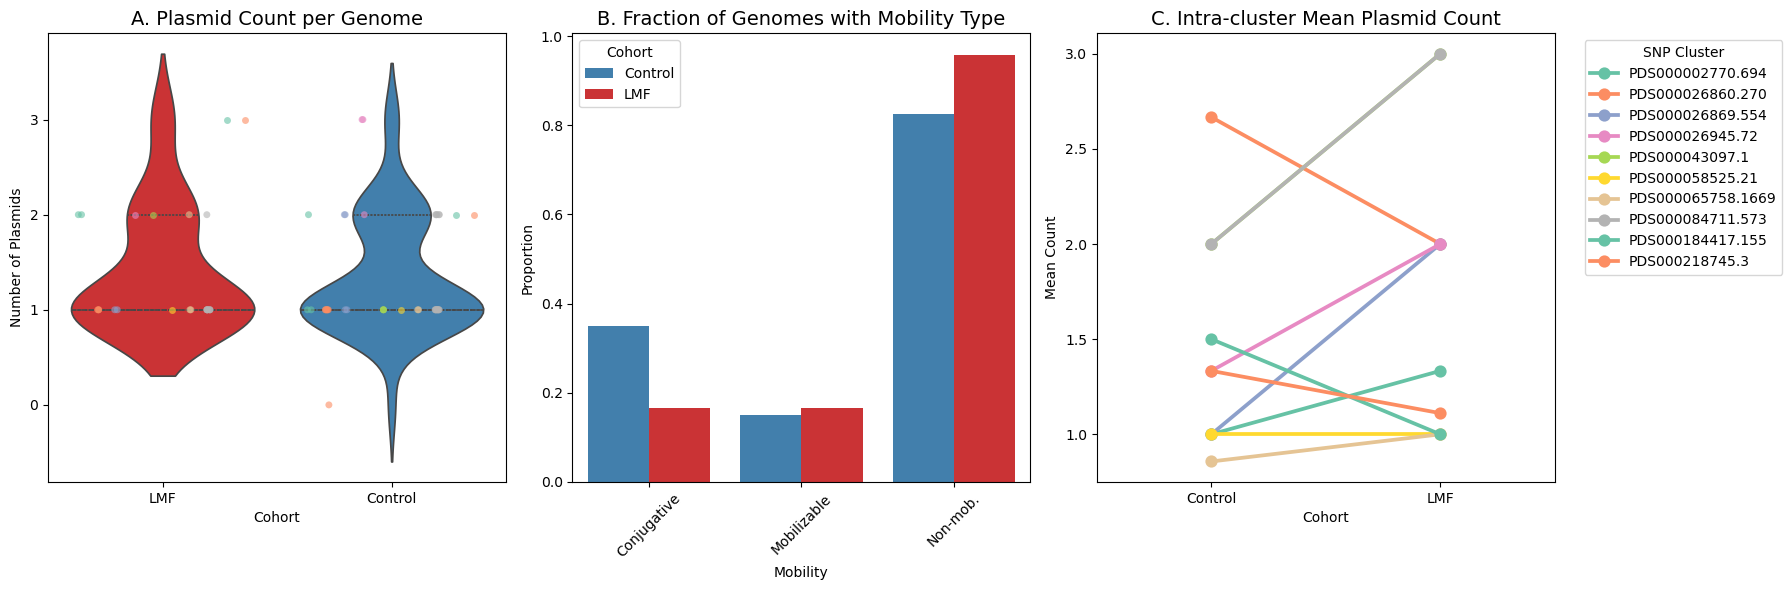

In [161]:
# ==========================================
# FIGURE 7: Burden and Mobility
# ==========================================
fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 6))

# 7A: Plasmid count Violin Plot
sns.violinplot(data=genome_df, x='Cohort', y='plasmid_count', ax=ax_a, inner='quartile', palette={'LMF': '#e31a1c', 'Control': '#3182bd'})
sns.stripplot(data=genome_df, x='Cohort', y='plasmid_count', hue='SNP cluster', ax=ax_a, dodge=True, alpha=0.6, palette='Set2')
ax_a.get_legend().remove()
ax_a.set_title("A. Plasmid Count per Genome", fontsize=14)
ax_a.set_ylabel("Number of Plasmids")

# 7B: Mobility Fraction Bar Plot
mobility_cols = ['has_conjugative', 'has_mobilizable', 'has_non_mobilizable']
mob_frac = genome_df.groupby('Cohort')[mobility_cols].mean().reset_index().melt(id_vars='Cohort', var_name='Mobility', value_name='Fraction')
sns.barplot(data=mob_frac, x='Mobility', y='Fraction', hue='Cohort', ax=ax_b, palette={'LMF': '#e31a1c', 'Control': '#3182bd'})
ax_b.set_title("B. Fraction of Genomes with Mobility Type", fontsize=14)
ax_b.set_ylabel("Proportion")
ax_b.set_xticklabels(['Conjugative', 'Mobilizable', 'Non-mob.'], rotation=45)

# 7C: Paired Dot Plot (SNP Cluster Means)
cluster_means = genome_df.groupby(['SNP cluster', 'Cohort'])['plasmid_count'].mean().reset_index()
# Only keep clusters that have both cohorts
mixed = cluster_means.groupby('SNP cluster')['Cohort'].nunique()
mixed_clusters = mixed[mixed == 2].index
cluster_means_mixed = cluster_means[cluster_means['SNP cluster'].isin(mixed_clusters)]

sns.pointplot(data=cluster_means_mixed, x='Cohort', y='plasmid_count', hue='SNP cluster', ax=ax_c, palette='Set2', markers='o', linestyles='-')
ax_c.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="SNP Cluster")
ax_c.set_title("C. Intra-cluster Mean Plasmid Count", fontsize=14)
ax_c.set_ylabel("Mean Count")

plt.tight_layout()
# plt.savefig('Figure_7_Burden_Mobility.tiff', dpi=600)

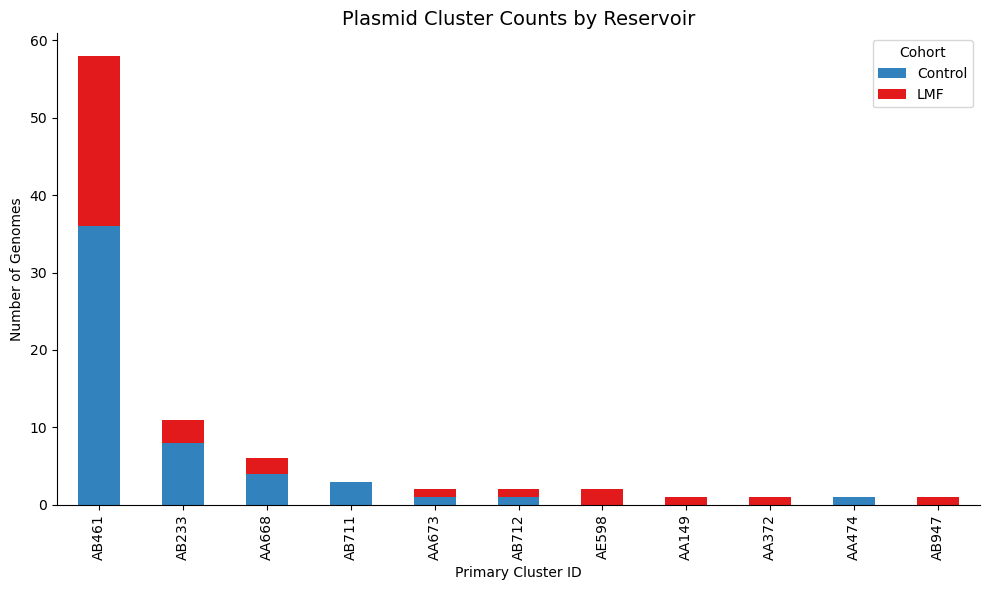

In [245]:
# 8B: Stacked Bar Chart of Cluster Counts
cluster_counts = pd.merge(mob_results[['Sample', 'primary_cluster_id']], metadata[['Assembly', 'Cohort']], left_on='Sample', right_on='Assembly')
stacked_data = cluster_counts.groupby(['primary_cluster_id', 'Cohort']).size().unstack(fill_value=0)
# Sort by total abundance
stacked_data['Total'] = stacked_data.sum(axis=1)
stacked_data = stacked_data.sort_values('Total', ascending=False).drop(columns='Total')

plt.figure(figsize=(10, 6))
stacked_data.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#3182bd', '#e31a1c'])
plt.title("Plasmid Cluster Counts by Reservoir", fontsize=14)
plt.ylabel("Number of Genomes")
plt.xlabel("Primary Cluster ID")
plt.legend(title='Cohort')
sns.despine()
plt.tight_layout()
plt.savefig('Figure_8B_StackedBar.tiff', dpi=600)

In [175]:
# Define high-contrast colors
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'} # Red and Blue
PRESENCE_COLOR = '#333333' # Dark gray for Presence
ABSENCE_COLOR = '#f0f0f0'  # Light gray for Absence

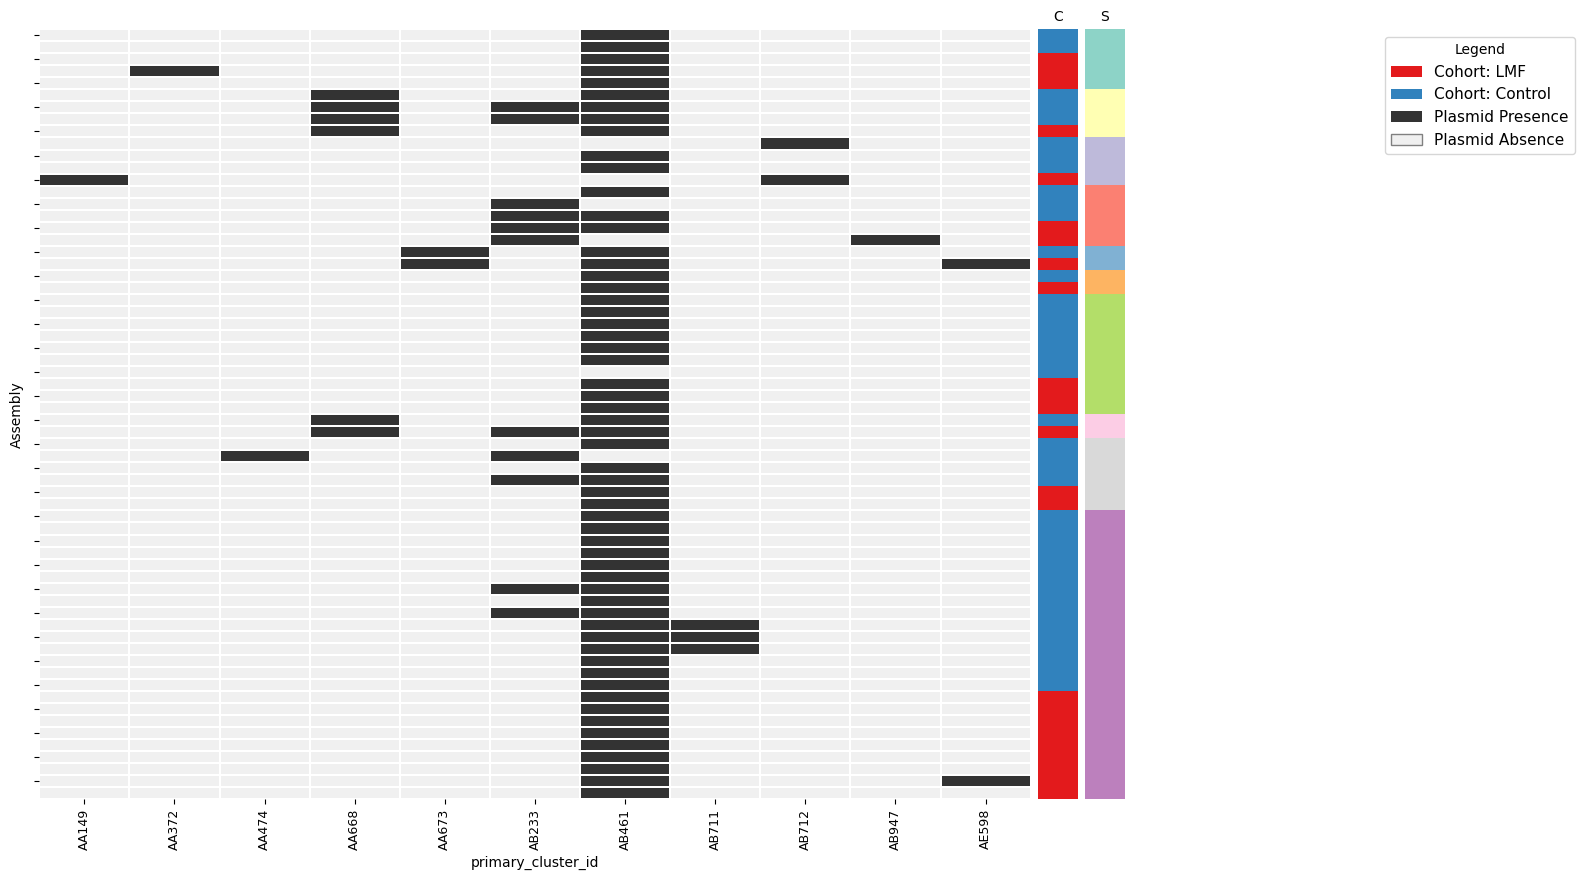

In [181]:
# ==========================================
# REVISED FIGURE 9: Backbone Heatmap
# ==========================================
cluster_matrix = mob_results.pivot_table(index='Sample', columns='primary_cluster_id', aggfunc='size', fill_value=0)
cluster_matrix = (cluster_matrix > 0).astype(int)
cluster_matrix_sorted = cluster_matrix.reindex(df_sorted['Assembly']).fillna(0).astype(int)

fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(14, 10), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.02})

cmap_binary = mcolors.ListedColormap([ABSENCE_COLOR, PRESENCE_COLOR])
sns.heatmap(cluster_matrix_sorted, ax=ax_main, cmap=cmap_binary, cbar=False, linewidths=0.1, linecolor='white')
ax_main.set_yticklabels([])
# ax_main.set_title("Figure 9. Presence/Absence of Plasmid Backbones", fontsize=15, pad=20)
ax_main.set_xticklabels(cluster_matrix_sorted.columns, rotation=90, fontsize=9)

# Annotation Bars
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C", fontsize=10)

cluster_ids, _ = pd.factorize(df_sorted['SNP cluster'])
cp = sns.color_palette("Set3", len(np.unique(cluster_ids)))
cluster_rgb = [cp[i] for i in cluster_ids]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S", fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor=COHORT_PALETTE['LMF'], label='Cohort: LMF'),
    Patch(facecolor=COHORT_PALETTE['Control'], label='Cohort: Control'),
    Patch(facecolor=PRESENCE_COLOR, label='Plasmid Presence'),
    Patch(facecolor=ABSENCE_COLOR, label='Plasmid Absence', edgecolor='gray')
]
ax_main.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', title="Legend", fontsize=11)

plt.savefig('Figure_9_Backbone_Heatmap_v2.tiff', dpi=600, bbox_inches='tight')

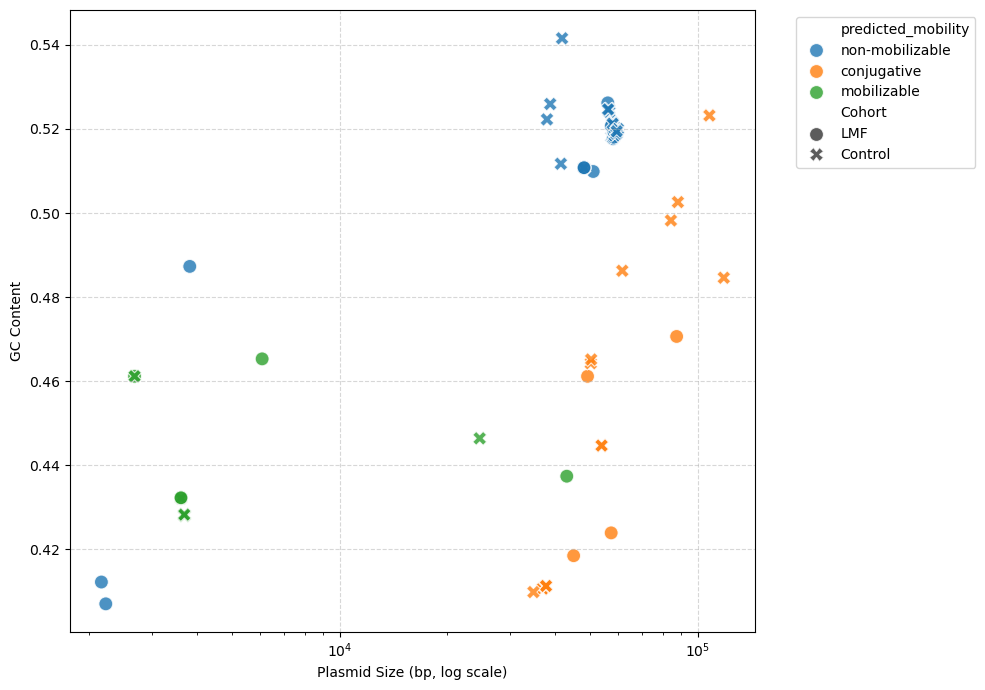

In [183]:
# ==========================================
# SUPP FIG S3: Size vs GC
# ==========================================
mob_meta = pd.merge(mob_results, metadata[['Assembly', 'Cohort']], left_on='Sample', right_on='Assembly')
plt.figure(figsize=(10, 7))
sns.scatterplot(data=mob_meta, x='size', y='gc', hue='predicted_mobility', style='Cohort', s=100, alpha=0.8)
plt.xscale('log')
# plt.title("Supp Fig S3: Plasmid Structural Properties", fontsize=14)
plt.xlabel("Plasmid Size (bp, log scale)")
plt.ylabel("GC Content")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Supp_Figure_S3_Properties.tiff', dpi=600)

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_16592\3122306779.py:56: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix_data_bin = matrix_data.applymap(lambda x: 1 if x >= 1 else 0)


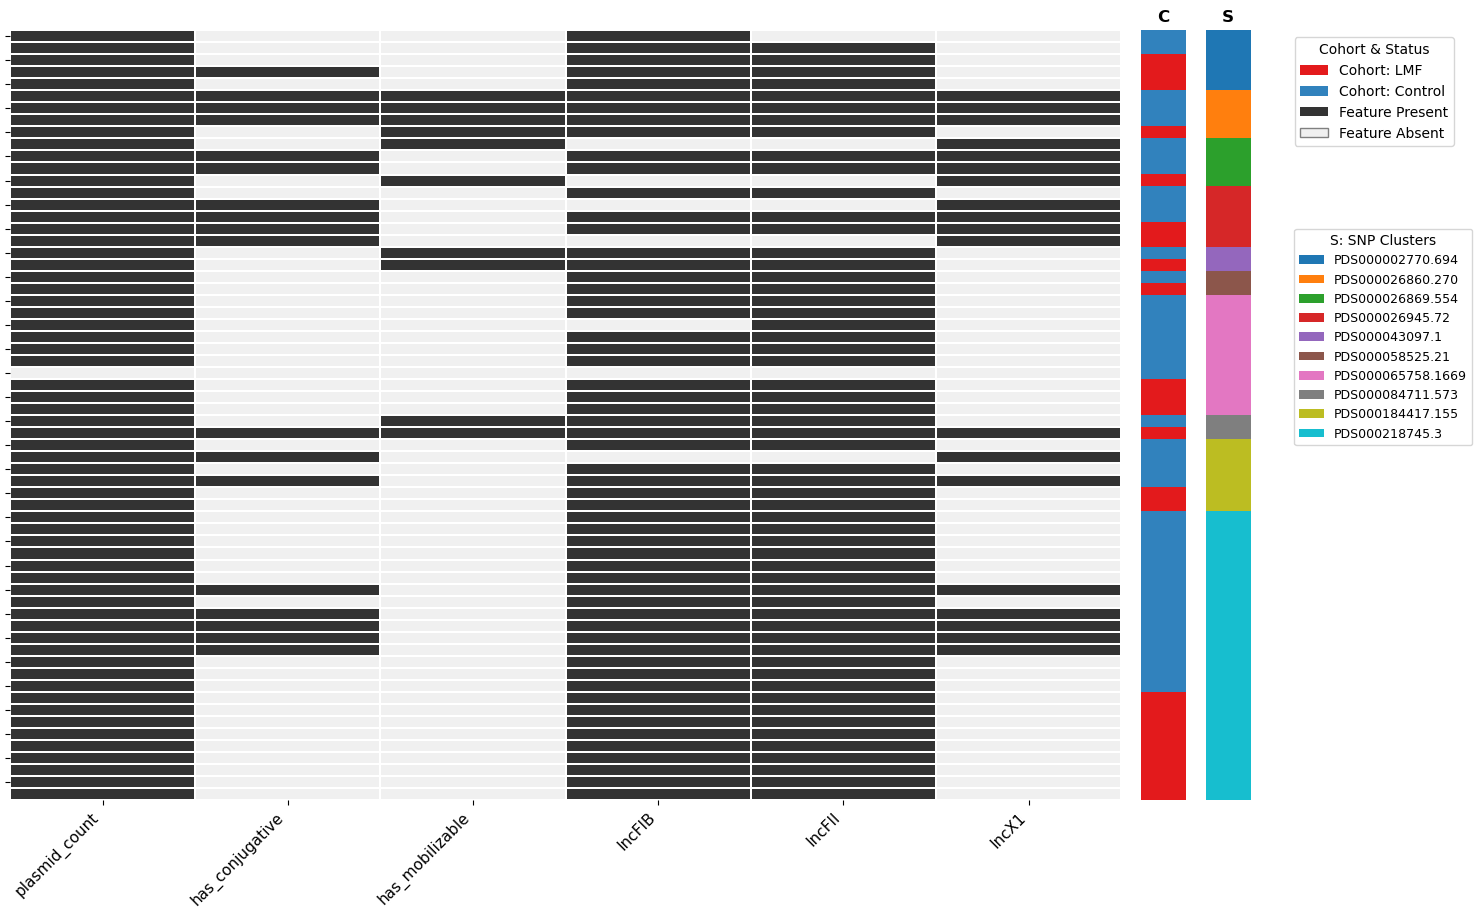

In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Load Data
metadata = pd.read_csv('../../old/Final_65.csv')
mob_results = pd.read_csv('master_mobtyper_results.csv')

# Preprocessing
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})

# Reconstruct plasmid count and mobility flags from MOB results
counts = mob_results.groupby('Sample').size().reset_index(name='plasmid_count')
mobility = mob_results.groupby('Sample')['predicted_mobility'].unique().reset_index()
mobility['has_conjugative'] = mobility['predicted_mobility'].apply(lambda x: 1 if 'conjugative' in x else 0)
mobility['has_mobilizable'] = mobility['predicted_mobility'].apply(lambda x: 1 if 'mobilizable' in x else 0)

# Merge back to metadata
df = pd.merge(metadata, counts, left_on='Assembly', right_on='Sample', how='left').fillna({'plasmid_count': 0})
df = pd.merge(df, mobility[['Sample', 'has_conjugative', 'has_mobilizable']], left_on='Assembly', right_on='Sample', how='left').fillna(0)

# Extract core replicons from MOB results
def check_rep(sample, rep):
    reps = mob_results[mob_results['Sample'] == sample]['rep_type(s)'].tolist()
    for r_str in reps:
        if isinstance(r_str, str) and rep in r_str:
            return 1
    return 0

for rep in ['IncFIB', 'IncFII', 'IncX1']:
    df[rep] = df['Assembly'].apply(lambda x: check_rep(x, rep))

# Sort for heatmap consistency
df_sorted = df.sort_values(['SNP cluster', 'Cohort']).reset_index(drop=True)

# Define Style (Matching Figure 9 exactly)
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'}
PRESENCE_COLOR = '#333333'
ABSENCE_COLOR = '#f0f0f0'

# SNP Cluster Palette
unique_clusters = df_sorted['SNP cluster'].unique()
cluster_colors_list = sns.color_palette("tab10", len(unique_clusters))
cluster_palette = dict(zip(unique_clusters, cluster_colors_list))

# Prepare Figure 10 Data
# We will binarize plasmid_count for the visual "Like 9" look, 
# but keep the labels as descriptive as possible.
features = ['plasmid_count', 'has_conjugative', 'has_mobilizable', 'IncFIB', 'IncFII', 'IncX1']
matrix_data = df_sorted[features].copy()
# Binarize plasmid_count only for the heatmap color mapping
matrix_data_bin = matrix_data.applymap(lambda x: 1 if x >= 1 else 0)

# ==========================================
# REVISED FIGURE 10: Integrated Matrix (v3 - Exact layout of Fig 9)
# ==========================================
fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(16, 10), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.05})

cmap_binary = mcolors.ListedColormap([ABSENCE_COLOR, PRESENCE_COLOR])
sns.heatmap(matrix_data_bin, ax=ax_main, cmap=cmap_binary, cbar=False, linewidths=0.1, linecolor='white')

ax_main.set_yticklabels([])
# ax_main.set_title("Figure 10. Integrated Genomic Feature Matrix", fontsize=16, pad=30)
ax_main.set_xticklabels(features, rotation=45, ha='right', fontsize=11)

# Annotation Bars (Same as Fig 9)
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C", fontsize=12, fontweight='bold')

cluster_rgb = [mcolors.to_rgb(cluster_palette[s]) for s in df_sorted['SNP cluster']]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S", fontsize=12, fontweight='bold')

# Legend (Same as Fig 9)
legend_elements_1 = [
    Patch(facecolor=COHORT_PALETTE['LMF'], label='Cohort: LMF'),
    Patch(facecolor=COHORT_PALETTE['Control'], label='Cohort: Control'),
    Patch(facecolor=PRESENCE_COLOR, label='Feature Present'),
    Patch(facecolor=ABSENCE_COLOR, label='Feature Absent', edgecolor='gray')
]
legend_elements_2 = [Patch(facecolor=cluster_palette[clus], label=clus) for clus in unique_clusters]

# Combined Legends
leg1 = ax_main.legend(handles=legend_elements_1, bbox_to_anchor=(1.15, 1), loc='upper left', title="Cohort & Status", fontsize=10)
ax_main.add_artist(leg1)
ax_main.legend(handles=legend_elements_2, bbox_to_anchor=(1.15, 0.75), loc='upper left', title="S: SNP Clusters", fontsize=9)

plt.savefig('Figure_10_Integrated_Matrix_v3.tiff', dpi=600, bbox_inches='tight')

# # Verify the output
# print("Figure 10 has been regenerated to match the style of Figure 9.")

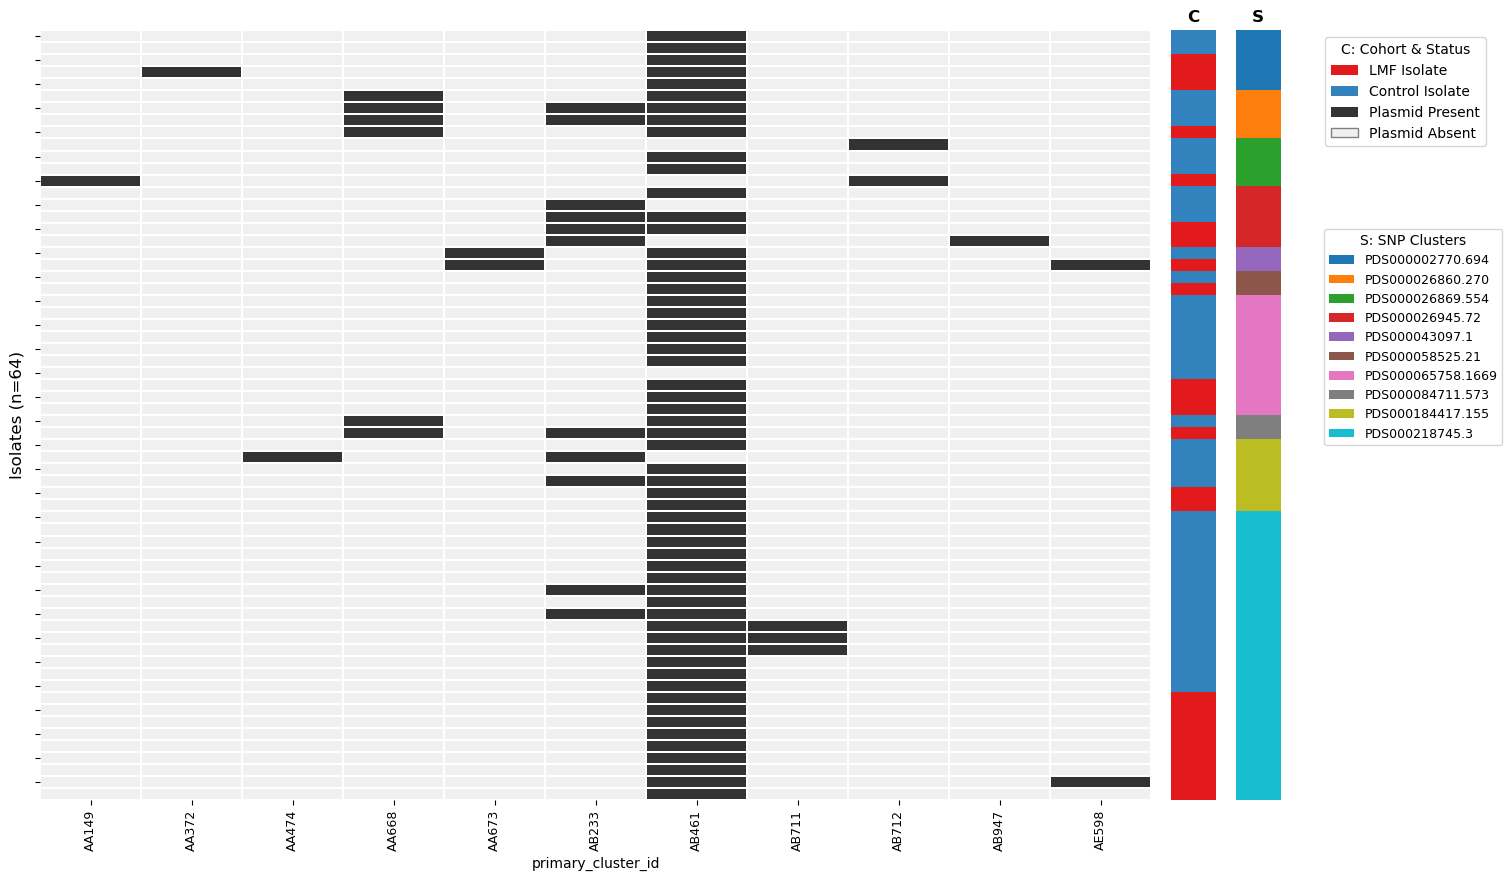

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# 1. Load Data
metadata = pd.read_csv('../../old/Final_65.csv')
mob_results = pd.read_csv('master_mobtyper_results.csv')

# 2. Preprocessing
# Filter out poor quality assembly
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})

# Sort by lineage for consistent heatmap ordering
df_sorted = metadata.sort_values(['SNP cluster', 'Cohort']).reset_index(drop=True)

# Define Palettes
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'}
PRESENCE_COLOR = '#333333'
ABSENCE_COLOR = '#f0f0f0'

unique_clusters = df_sorted['SNP cluster'].unique()
cluster_colors_list = sns.color_palette("tab10", len(unique_clusters))
cluster_palette = dict(zip(unique_clusters, cluster_colors_list))

# 3. Prepare Cluster Matrix (Backbones)
cluster_matrix = mob_results.pivot_table(index='Sample', columns='primary_cluster_id', aggfunc='size', fill_value=0)
cluster_matrix = (cluster_matrix > 0).astype(int)
cluster_matrix_sorted = cluster_matrix.reindex(df_sorted['Assembly']).fillna(0).astype(int)

# 4. Generate FIGURE 9 (Backbone Heatmap) in style of Figure 10
fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(16, 10), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.05})

cmap_binary = mcolors.ListedColormap([ABSENCE_COLOR, PRESENCE_COLOR])
sns.heatmap(cluster_matrix_sorted, ax=ax_main, cmap=cmap_binary, cbar=False, linewidths=0.1, linecolor='white')

ax_main.set_yticklabels([])
# ax_main.set_title("Figure 9. Distribution of Reconstructed Plasmid Backbones", fontsize=16, pad=30)
ax_main.set_xticklabels(cluster_matrix_sorted.columns, rotation=90, fontsize=9)
ax_main.set_ylabel(f"Isolates (n={len(df_sorted)})", fontsize=12)

# Annotation Bars (C and S)
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C", fontsize=12, fontweight='bold')

cluster_rgb = [mcolors.to_rgb(cluster_palette[s]) for s in df_sorted['SNP cluster']]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S", fontsize=12, fontweight='bold')

# LEGENDS
legend_elements_1 = [
    Patch(facecolor=COHORT_PALETTE['LMF'], label='LMF Isolate'),
    Patch(facecolor=COHORT_PALETTE['Control'], label='Control Isolate'),
    Patch(facecolor=PRESENCE_COLOR, label='Plasmid Present'),
    Patch(facecolor=ABSENCE_COLOR, label='Plasmid Absent', edgecolor='gray')
]
legend_elements_2 = [Patch(facecolor=cluster_palette[clus], label=clus) for clus in unique_clusters]

# Combine Legends using the artist approach for separate legends if needed, or grouped
leg1 = ax_main.legend(handles=legend_elements_1, bbox_to_anchor=(1.15, 1), loc='upper left', title="C: Cohort & Status", fontsize=10)
ax_main.add_artist(leg1)
ax_main.legend(handles=legend_elements_2, bbox_to_anchor=(1.15, 0.75), loc='upper left', title="S: SNP Clusters", fontsize=9)

plt.savefig('Figure_9_Backbone_Heatmap_v3.tiff', dpi=600, bbox_inches='tight')
# print("Figure 9 has been updated to match Figure 10 style.")